In [1]:
%pip install torch

  Using cached torch-2.13.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached filelock-3.29.7-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached cuda_toolkit-13.0.3.0-py2.py3-none-any.whl.metadata (17 kB)
  Using cached cuda_bindings-13.3.1-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.5 kB)
  Using cached nvidia_cudnn_cu13-9.20.0.48-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.7.1-cp311-cp311-manylinux_2_27_x86_

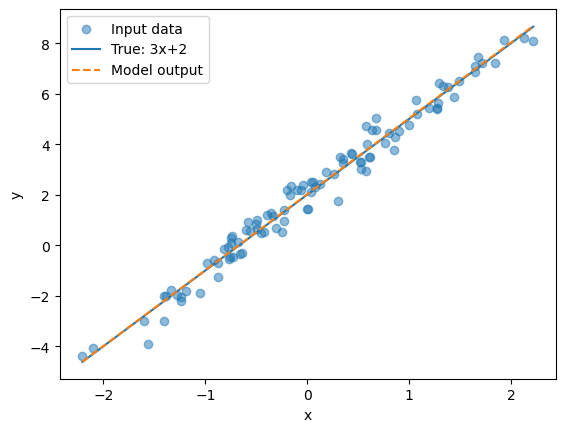

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(42)

x = torch.randn(100, 1)
y_true = 3 * x + 2
y = y_true + 0.5 * torch.randn(100, 1)

model, loss_fn = nn.Linear(1, 1), nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for _ in range(100):
    loss = loss_fn(model(x), y); optimizer.zero_grad(); loss.backward(); optimizer.step()

x_plot = torch.linspace(x.min(), x.max(), 200).reshape(-1, 1)

with torch.no_grad(): y_model = model(x_plot)
plt.scatter(x, y, alpha=0.5, label="Input data"); plt.plot(x_plot, 3*x_plot+2, label="True: 3x+2")
plt.plot(x_plot, y_model, linestyle="--", label="Model output"); plt.legend(); plt.xlabel("x"); plt.ylabel("y"); plt.show()